#Detecção de Anomalias em Transações em Python

In [ ]:
# Definindo os dados utilizados
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Verificando se há dados faltantes
df.info()

df["Class"].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,proportion
Class,
0,0.998273
1,0.001727


In [ ]:
# Criando Variáveis que ajudam o modelo

import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_log,Amount_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,-0.073403


In [ ]:
from sklearn.model_selection import train_test_split

# Selecionando TODAS as características existentes no DataFrame 'df', exceto a coluna 'Class'.
# Isso inclui 'Time', 'Amount', 'Amount_log' e 'Amount_scaled' além das features 'V' originais.
X = df.drop("Class", axis = 1)
y = df["Class"] # o que queremos saber, as categorias

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
# Separando as features (X) da variável alvo (y)
# X_full conterá todas as features (Time, Amount, Amount_log, Amount_scaled, V1-V28)
features_full = df.drop("Class", axis=1).columns.tolist()
X_full = df[features_full]
y = df["Class"]

# X_reduced conterá apenas as features V1-V28 e Amount_scaled
features_reduced = ['V' + str(i) for i in range(1, 29)] + ['Amount_scaled']
X_reduced = df[features_reduced]

# Divisão dos dados para o conjunto FULL
X_train, X_test, y_train, y_test = train_test_split(X_full, y, stratify=y, test_size=0.2, random_state=42)

# Divisão dos dados para o conjunto REDUZIDO
X_train_reduced, X_test_reduced, _, _ = train_test_split(X_reduced, y, stratify=y, test_size=0.2, random_state=42)

print("Conjuntos de dados preparados:")
print(f"X_train (full features) shape: {X_train.shape}")
print(f"X_test (full features) shape: {X_test.shape}")
print(f"X_train_reduced (reduced features) shape: {X_train_reduced.shape}")
print(f"X_test_reduced (reduced features) shape: {X_test_reduced.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Conjuntos de dados preparados:
X_train (full features) shape: (227845, 32)
X_test (full features) shape: (56962, 32)
X_train_reduced (reduced features) shape: (227845, 29)
X_test_reduced (reduced features) shape: (56962, 29)
y_train shape: (227845,)
y_test shape: (56962,)


#Regressão Logística

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.72      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.86      0.88     56962
weighted avg       1.00      1.00      1.00     56962



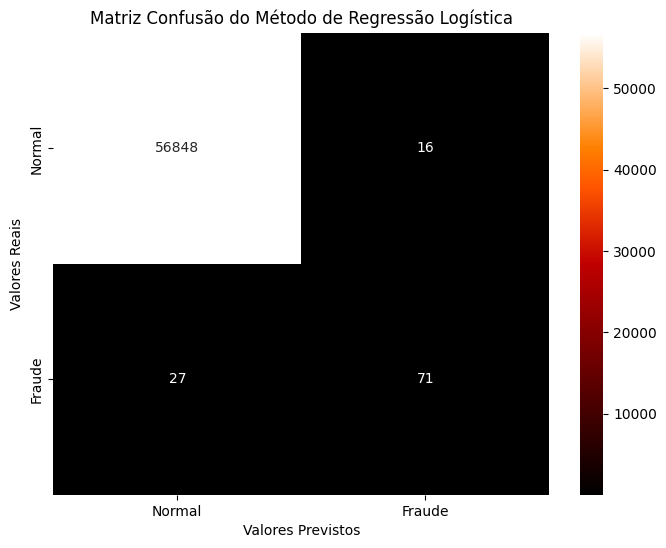

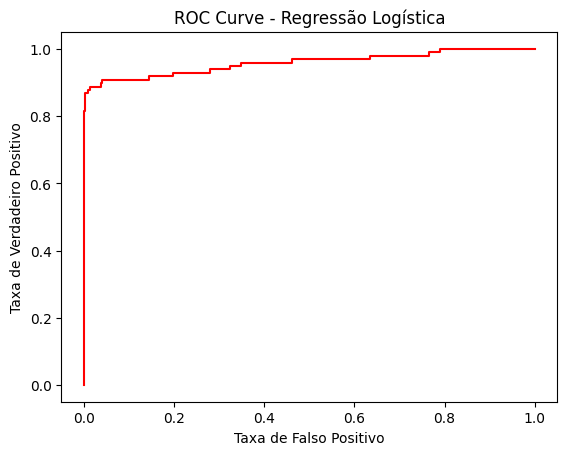

AUC:  0.9584574509319765



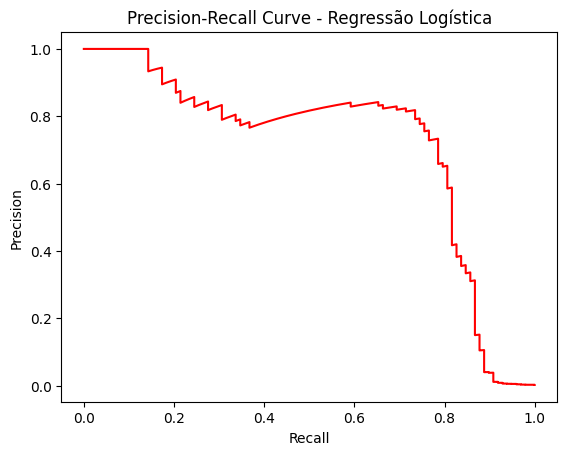

In [ ]:
from sklearn.linear_model import LogisticRegression

RL_model = LogisticRegression(max_iter=1000) # Aumentado max_iter para auxiliar na convergência

RL_model.fit(X_train, y_train)

y_pred_RL = RL_model.predict(X_test)

# Visualizando Métricas

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_RL))

# Matriz Confusão

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

RL_matriz_confusao = confusion_matrix(y_test, y_pred_RL)

plt.figure(figsize=(8, 6))
sns.heatmap(RL_matriz_confusao, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de Regressão Logística')
plt.show()

print()

# Curva ROC

from sklearn.metrics import roc_curve, roc_auc_score

y_probs_RL = RL_model.predict_proba(X_test)[:,1]

fpr_RL, tpr_RL, _ = roc_curve(y_test, y_probs_RL)

plt.plot(fpr_RL, tpr_RL, color='red') # Changed color
plt.title("ROC Curve - Regressão Logística")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC: ", roc_auc_score(y_test, y_probs_RL))

print()
# Curva Precision-Recall

from sklearn.metrics import precision_recall_curve

precision_RL, recall_RL, _ = precision_recall_curve(y_test, y_probs_RL)

plt.plot(recall_RL, precision_RL, color='red') # Changed color
plt.title("Precision-Recall Curve - Regressão Logística")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



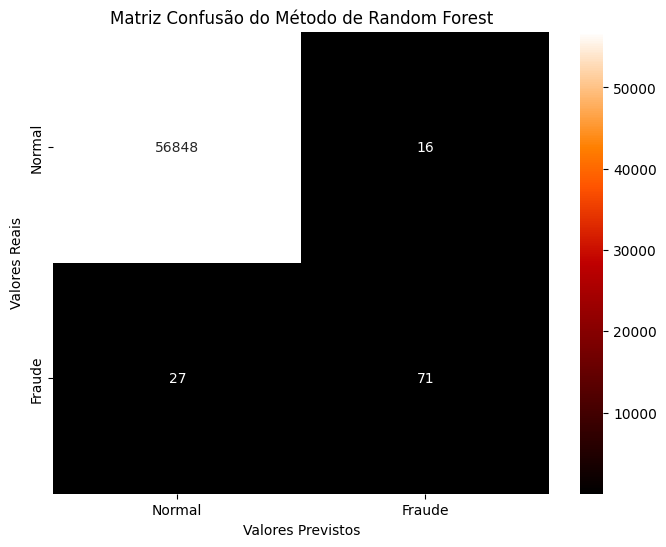

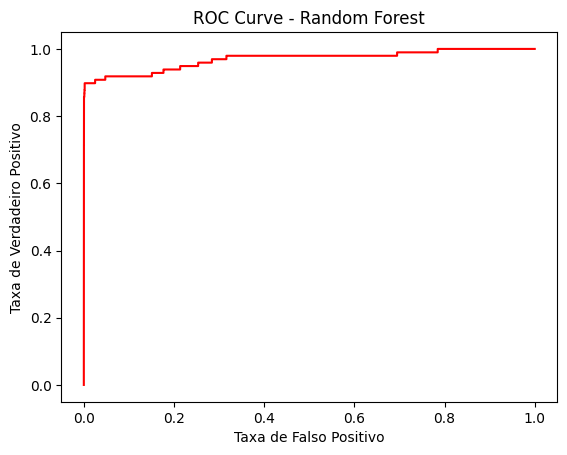

AUC - Random Forest:  0.9584574509319765



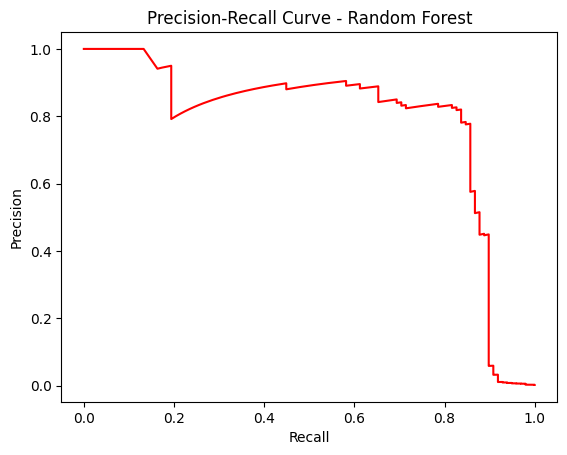

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(
    n_estimators=50, #escolhendo 50 árvores
    max_depth=10, #limitando a profundidade das árvores para evitar overfitng = quando o modelo decora os dados de treino e na hora de testar ele não consegue classificar os dados
    class_weight="balanced", #ajustando autimaticamente o peso das classes, equilibrando o peso das classes para que nenhuma seja ignorada
    n_jobs=-1,
    random_state=42
)

RF.fit(X_train, y_train)

y_pred_RF = RF.predict(X_test)

print(classification_report(y_test, y_pred_RF))

# Matriz Confusão

RF_matriz_confusao = confusion_matrix(y_test, y_pred_RF)

plt.figure(figsize=(8, 6))
sns.heatmap(RL_matriz_confusao, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de Random Forest')
plt.show()

print()

# Curva ROC

y_probs_RF = RF.predict_proba(X_test)[:,1]

fpr_RF, tpr_RF, _ = roc_curve(y_test, y_probs_RF)

plt.plot(fpr_RF, tpr_RF, color='red') # Changed color
plt.title("ROC Curve - Random Forest")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC - Random Forest: ", roc_auc_score(y_test, y_probs_RL))

print()
# Curva Precision-Recall

precision_RF, recall_RF, _ = precision_recall_curve(y_test, y_probs_RF)

plt.plot(recall_RF, precision_RF, color='red') # Changed color
plt.title("Precision-Recall Curve - Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:33:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



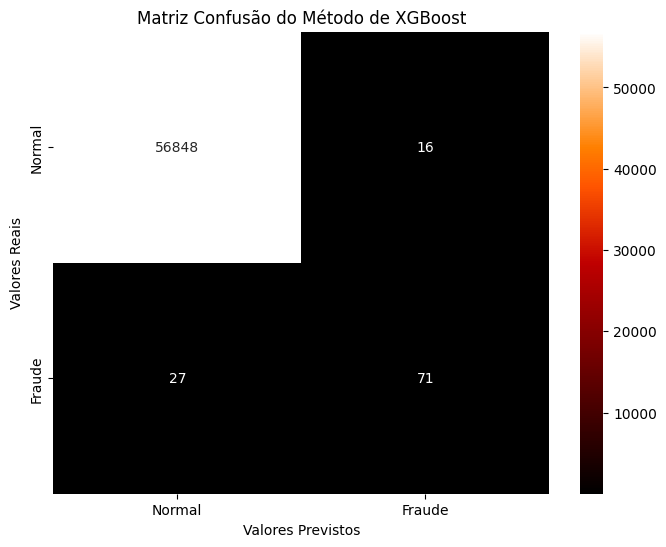

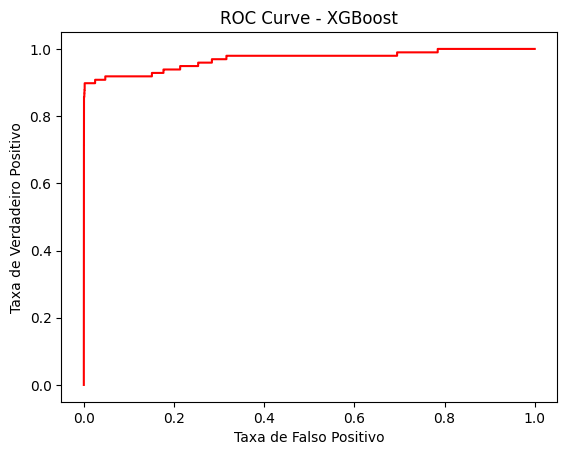

AUC - XGBoost:  0.9733723786363165



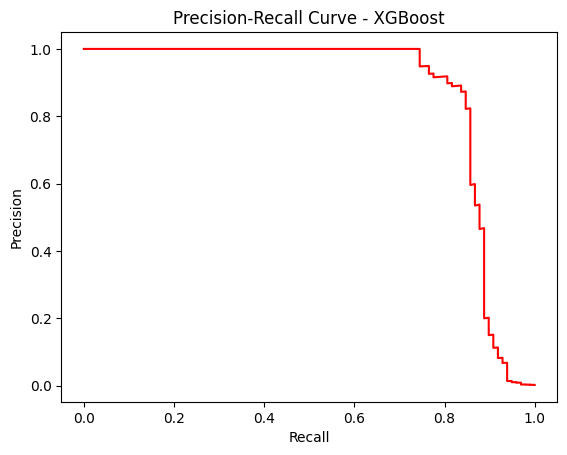

In [ ]:
from xgboost import XGBClassifier

XGB = XGBClassifier(
    scale_pos_weight=10, # ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)

XGB.fit(X_train, y_train)

y_pred_XGB = XGB.predict(X_test)

print(classification_report(y_test, y_pred_XGB))

# Matriz Confusão

XGB_matriz_confusao = confusion_matrix(y_test, y_pred_XGB)

plt.figure(figsize=(8, 6))
sns.heatmap(RL_matriz_confusao, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de XGBoost')
plt.show()

print()

# Curva ROC

y_probs_XGB = XGB.predict_proba(X_test)[:,1]

fpr_XGB, tpr_XGB, _ = roc_curve(y_test, y_probs_XGB)

plt.plot(fpr_RF, tpr_RF, color='red') # Changed color
plt.title("ROC Curve - XGBoost")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC - XGBoost: ", roc_auc_score(y_test, y_probs_XGB))

print()
# Curva Precision-Recall

precision_XGB, recall_XGB, _ = precision_recall_curve(y_test, y_probs_XGB)

plt.plot(recall_XGB, precision_XGB, color='red') # Changed color
plt.title("Precision-Recall Curve - XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#Isolation Forest

Classification Report (Isolation Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.23      0.24      0.24        98

    accuracy                           1.00     56962
   macro avg       0.61      0.62      0.62     56962
weighted avg       1.00      1.00      1.00     56962



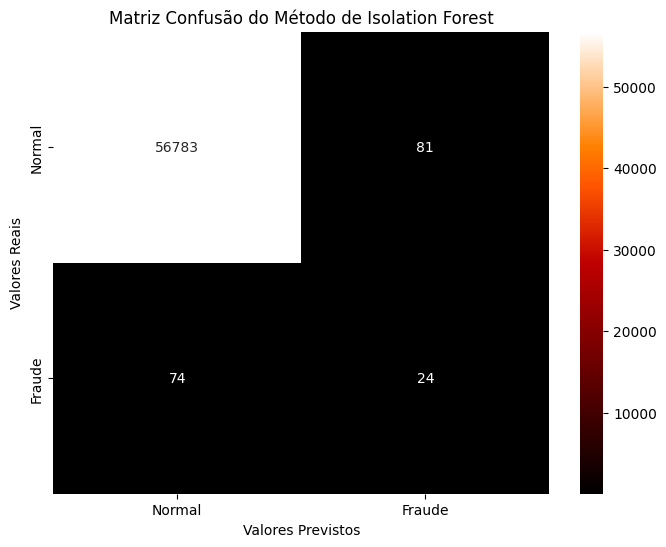

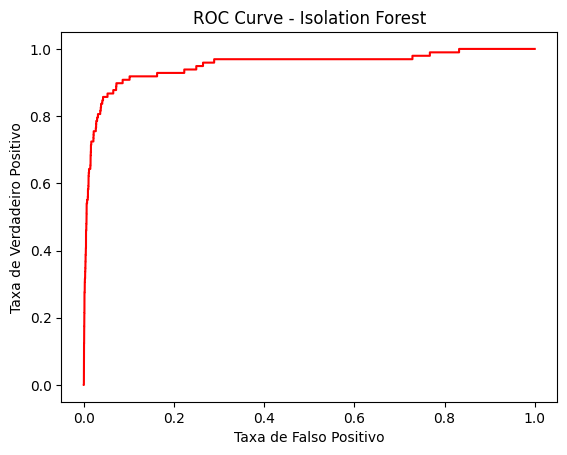

AUC - Isolation Forest:  0.9517994240464897



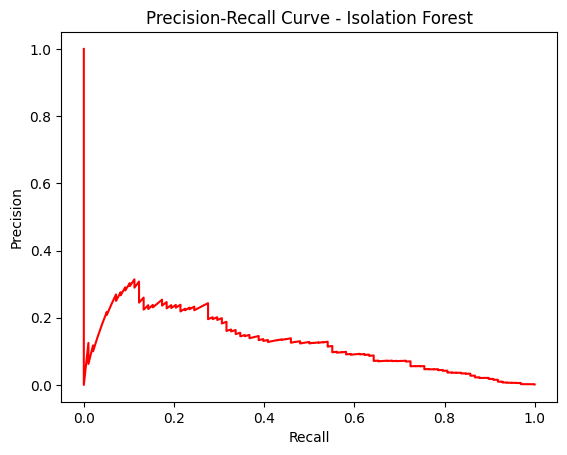

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Instantiate the Isolation Forest model
# We set contamination based on the observed proportion of the fraud class in the data.
IF = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.001727, # This value comes from df["Class"].value_counts(normalize=True) earlier
    random_state=42,
    n_jobs=-1
)

# Fit the model on the training data. Isolation Forest is an unsupervised method.
IF.fit(X_train)

# Predict on the test set
# Isolation Forest returns 1 for inliers (normal) and -1 for outliers (fraud).
# We need to map these to 0 (normal) and 1 (fraud) to match y_test.
y_pred_IF_raw = IF.predict(X_test)
y_pred_IF = np.where(y_pred_IF_raw == -1, 1, 0)

print("Classification Report (Isolation Forest):")
print(classification_report(y_test, y_pred_IF))

# Matriz Confusão
IF_matriz_confusao = confusion_matrix(y_test, y_pred_IF)

plt.figure(figsize=(8, 6))
sns.heatmap(IF_matriz_confusao, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de Isolation Forest')
plt.show()

print()

# Curva ROC
# For ROC/PR curves, we need a score where higher values mean more likely the positive class (fraud).
# Isolation Forest's decision_function returns anomaly scores: lower score implies more anomalous.
# So, we negate the decision_function output to align with the ROC/PR curve expectations.
y_scores_IF = -IF.decision_function(X_test)

fpr_IF, tpr_IF, _ = roc_curve(y_test, y_scores_IF)

plt.plot(fpr_IF, tpr_IF, color='red') # Using a new color for distinct visualization
plt.title("ROC Curve - Isolation Forest")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC - Isolation Forest: ", roc_auc_score(y_test, y_scores_IF))

print()
# Curva Precision-Recall

precision_IF, recall_IF, _ = precision_recall_curve(y_test, y_scores_IF)

plt.plot(recall_IF, precision_IF, color='red') # Using a new color
plt.title("Precision-Recall Curve - Isolation Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#SVM

Fitting SVM model (this may take a while)...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM model fitted.
Classification Report (SVM):
              precision    recall  f1-score   support

           0       1.00      0.45      0.62     56864
           1       0.00      0.78      0.00        98

    accuracy                           0.45     56962
   macro avg       0.50      0.61      0.31     56962
weighted avg       1.00      0.45      0.62     56962



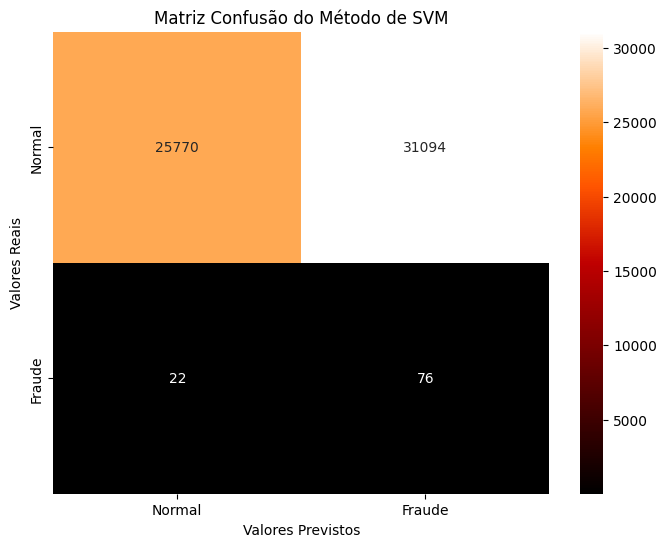

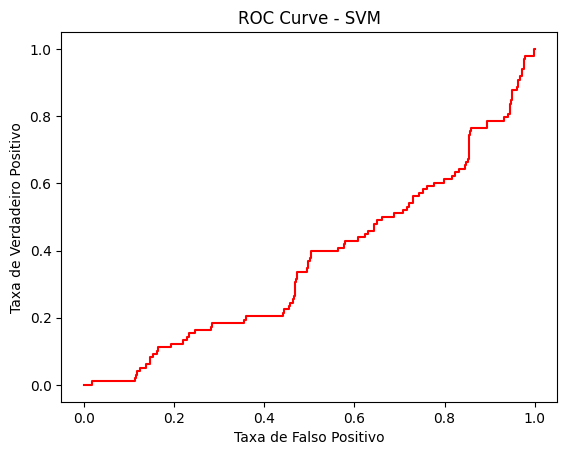

AUC - SVM:  0.3689346869867812



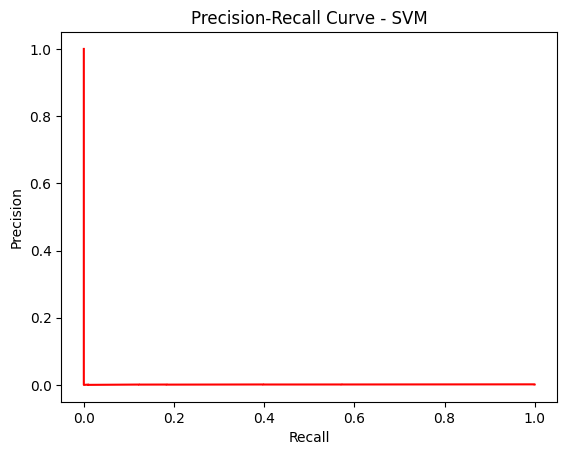

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Instantiate the SVM model
# Setting probability=True allows for predict_proba, which is needed for ROC and PR curves.
# class_weight='balanced' helps handle the imbalanced dataset.
# A linear kernel is often faster for large datasets, but radial basis function (rbf) is common too.
# max_iter is increased further to help with convergence on this dataset.
SVM_model = SVC(kernel='linear', C=1, class_weight='balanced', random_state=42, probability=True, max_iter=5000)

print("Fitting SVM model (this may take a while)...")
SVM_model.fit(X_train, y_train)
print("SVM model fitted.")

y_pred_SVM = SVM_model.predict(X_test)

print("Classification Report (SVM):")
print(classification_report(y_test, y_pred_SVM))

# Matriz Confusão
SVM_matriz_confusao = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(8, 6))
sns.heatmap(SVM_matriz_confusao, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de SVM')
plt.show()

print()

# Curva ROC

y_probs_SVM = SVM_model.predict_proba(X_test)[:,1]

fpr_SVM, tpr_SVM, _ = roc_curve(y_test, y_probs_SVM)

plt.plot(fpr_SVM, tpr_SVM, color='red') # Using a new color for distinct visualization
plt.title("ROC Curve - SVM")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC - SVM: ", roc_auc_score(y_test, y_probs_SVM))

print()
# Curva Precision-Recall

precision_SVM, recall_SVM, _ = precision_recall_curve(y_test, y_probs_SVM)

plt.plot(recall_SVM, precision_SVM, color='red') # Using the same color as ROC
plt.title("Precision-Recall Curve - SVM")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

#Threshold

### Threshold Optimization for Logistic Regression

We will find the optimal threshold for the Logistic Regression model by maximizing the F1-score. This metric balances precision and recall, which is often crucial in imbalanced datasets like fraud detection.

Optimal Threshold for Logistic Regression: 0.4444

Classification Report (Logistic Regression with Optimal Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.73      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.87      0.89     56962
weighted avg       1.00      1.00      1.00     56962



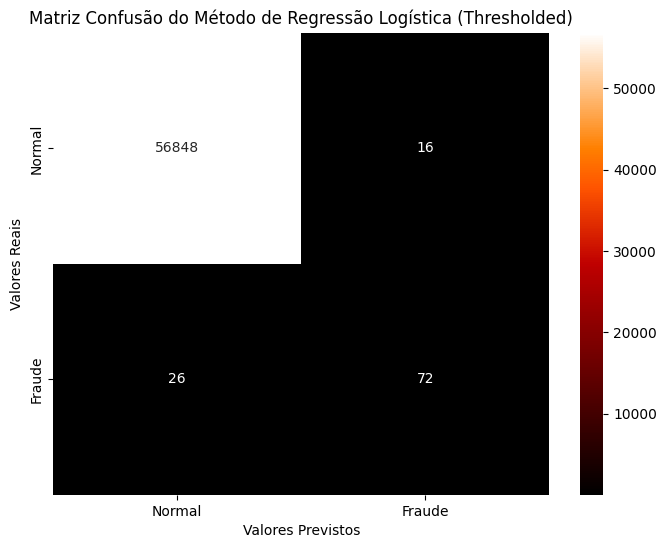

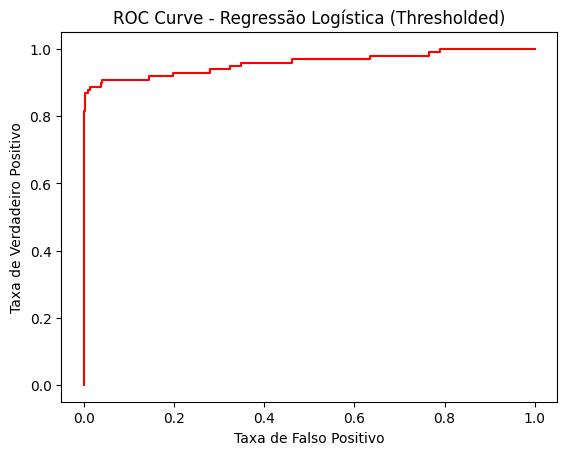

AUC:  0.9584574509319765



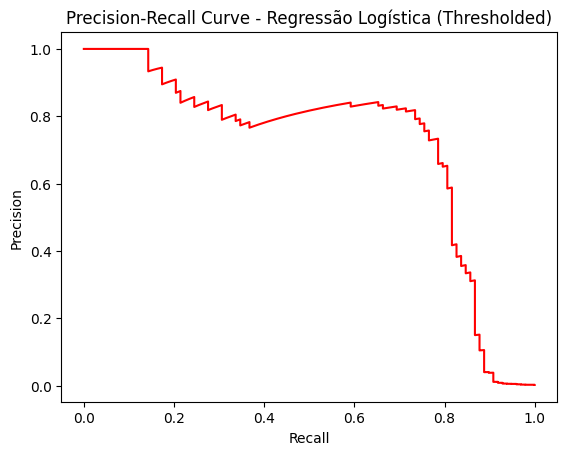

In [ ]:
from sklearn.metrics import f1_score

# Get predicted probabilities for the positive class (fraud)
y_probs_RL = RL_model.predict_proba(X_test)[:, 1]

# Define a range of thresholds to test
thresholds = np.linspace(0, 1, 100)

f1_scores_RL = []
for threshold in thresholds:
    y_pred_threshold = (y_probs_RL >= threshold).astype(int)
    f1_scores_RL.append(f1_score(y_test, y_pred_threshold))

# Find the optimal threshold
optimal_threshold_RL = thresholds[np.argmax(f1_scores_RL)]
print(f"Optimal Threshold for Logistic Regression: {optimal_threshold_RL:.4f}")

# Apply the optimal threshold to get predictions
y_pred_RL_thresholded = (y_probs_RL >= optimal_threshold_RL).astype(int)

print("\nClassification Report (Logistic Regression with Optimal Threshold):")
print(classification_report(y_test, y_pred_RL_thresholded))

# Matriz Confusão with Optimal Threshold
RL_matriz_confusao_thresholded = confusion_matrix(y_test, y_pred_RL_thresholded)

plt.figure(figsize=(8, 6))
sns.heatmap(RL_matriz_confusao_thresholded, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de Regressão Logística (Thresholded)')
plt.show()

print()

# ROC Curve with Optimal Threshold
plt.plot(fpr_RL, tpr_RL, color='red')
plt.title("ROC Curve - Regressão Logística (Thresholded)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC: ", roc_auc_score(y_test, y_probs_RL))

print()
# Precision-Recall Curve with Optimal Threshold
plt.plot(recall_RL, precision_RL, color='red')
plt.title("Precision-Recall Curve - Regressão Logística (Thresholded)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Threshold Optimization for Random Forest

Now, let's optimize the threshold for the Random Forest model using the same F1-score maximization approach.

Optimal Threshold for Random Forest: 0.4242

Classification Report (Random Forest with Optimal Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.84      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962



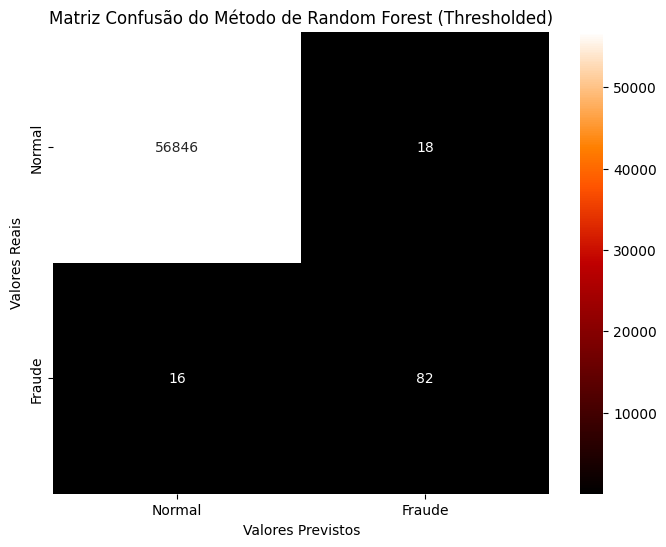

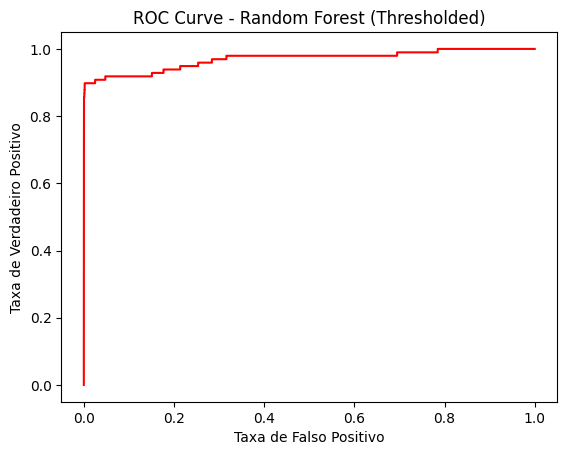

AUC - Random Forest:  0.969758941491622



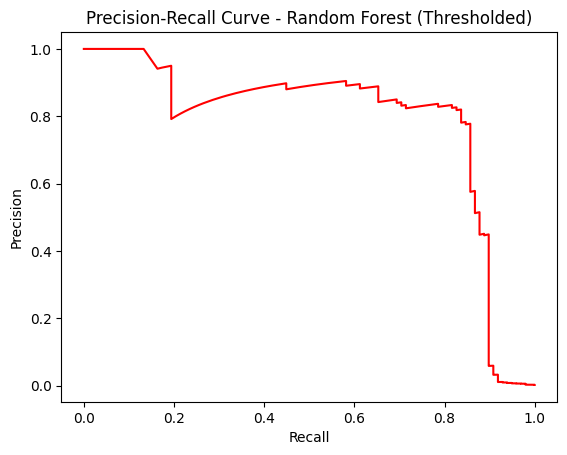

In [ ]:
# Get predicted probabilities for the positive class (fraud)
y_probs_RF = RF.predict_proba(X_test)[:, 1]

f1_scores_RF = []
for threshold in thresholds:
    y_pred_threshold = (y_probs_RF >= threshold).astype(int)
    f1_scores_RF.append(f1_score(y_test, y_pred_threshold))

# Find the optimal threshold
optimal_threshold_RF = thresholds[np.argmax(f1_scores_RF)]
print(f"Optimal Threshold for Random Forest: {optimal_threshold_RF:.4f}")

# Apply the optimal threshold to get predictions
y_pred_RF_thresholded = (y_probs_RF >= optimal_threshold_RF).astype(int)

print("\nClassification Report (Random Forest with Optimal Threshold):")
print(classification_report(y_test, y_pred_RF_thresholded))

# Matriz Confusão with Optimal Threshold
RF_matriz_confusao_thresholded = confusion_matrix(y_test, y_pred_RF_thresholded)

plt.figure(figsize=(8, 6))
sns.heatmap(RF_matriz_confusao_thresholded, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de Random Forest (Thresholded)')
plt.show()

print()

# ROC Curve with Optimal Threshold
plt.plot(fpr_RF, tpr_RF, color='red')
plt.title("ROC Curve - Random Forest (Thresholded)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC - Random Forest: ", roc_auc_score(y_test, y_probs_RF))

print()
# Precision-Recall Curve with Optimal Threshold
plt.plot(recall_RF, precision_RF, color='red')
plt.title("Precision-Recall Curve - Random Forest (Thresholded)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Threshold Optimization for XGBoost

Next, we will optimize the threshold for the XGBoost model.

Optimal Threshold for XGBoost: 0.5051

Classification Report (XGBoost with Optimal Threshold):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



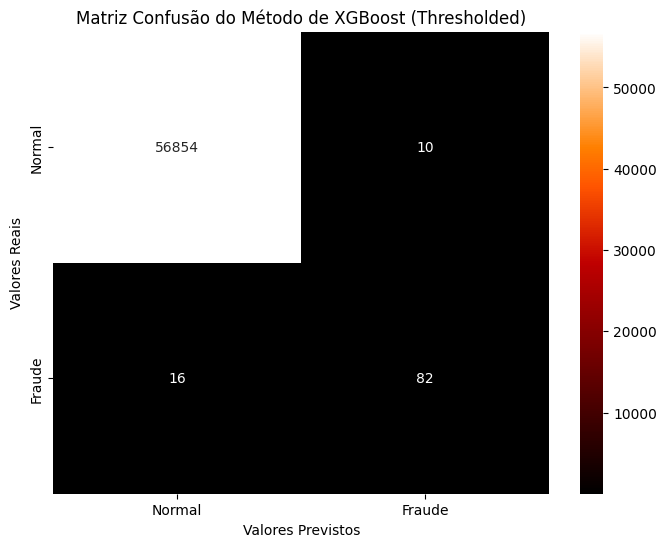

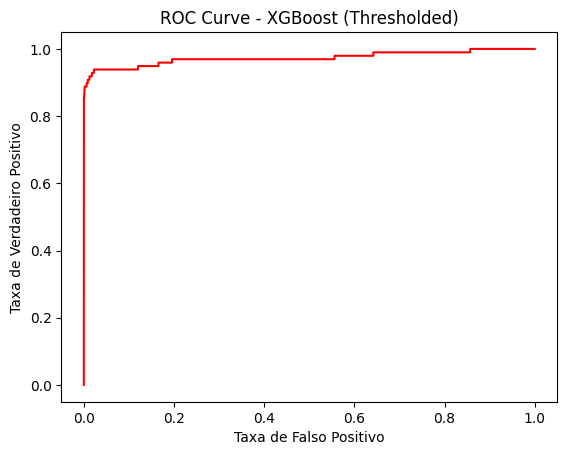

AUC - XGBoost:  0.9733723786363165



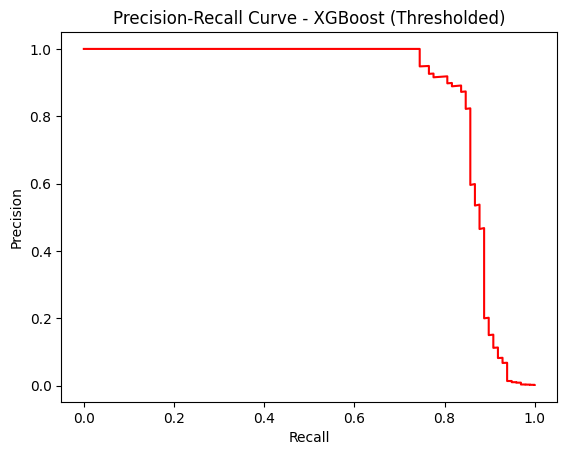

In [ ]:
# Get predicted probabilities for the positive class (fraud)
y_probs_XGB = XGB.predict_proba(X_test)[:, 1]

f1_scores_XGB = []
for threshold in thresholds:
    y_pred_threshold = (y_probs_XGB >= threshold).astype(int)
    f1_scores_XGB.append(f1_score(y_test, y_pred_threshold))

# Find the optimal threshold
optimal_threshold_XGB = thresholds[np.argmax(f1_scores_XGB)]
print(f"Optimal Threshold for XGBoost: {optimal_threshold_XGB:.4f}")

# Apply the optimal threshold to get predictions
y_pred_XGB_thresholded = (y_probs_XGB >= optimal_threshold_XGB).astype(int)

print("\nClassification Report (XGBoost with Optimal Threshold):")
print(classification_report(y_test, y_pred_XGB_thresholded))

# Matriz Confusão with Optimal Threshold
XGB_matriz_confusao_thresholded = confusion_matrix(y_test, y_pred_XGB_thresholded)

plt.figure(figsize=(8, 6))
sns.heatmap(XGB_matriz_confusao_thresholded, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de XGBoost (Thresholded)')
plt.show()

print()

# ROC Curve with Optimal Threshold
plt.plot(fpr_XGB, tpr_XGB, color='red')
plt.title("ROC Curve - XGBoost (Thresholded)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC - XGBoost: ", roc_auc_score(y_test, y_probs_XGB))

print()
# Precision-Recall Curve with Optimal Threshold
plt.plot(recall_XGB, precision_XGB, color='red')
plt.title("Precision-Recall Curve - XGBoost (Thresholded)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Threshold Optimization for SVM

Finally, we will optimize the threshold for the SVM model.

Optimal Threshold for SVM: 0.0000

Classification Report (SVM with Optimal Threshold):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56864
           1       0.00      1.00      0.00        98

    accuracy                           0.00     56962
   macro avg       0.00      0.50      0.00     56962
weighted avg       0.00      0.00      0.00     56962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


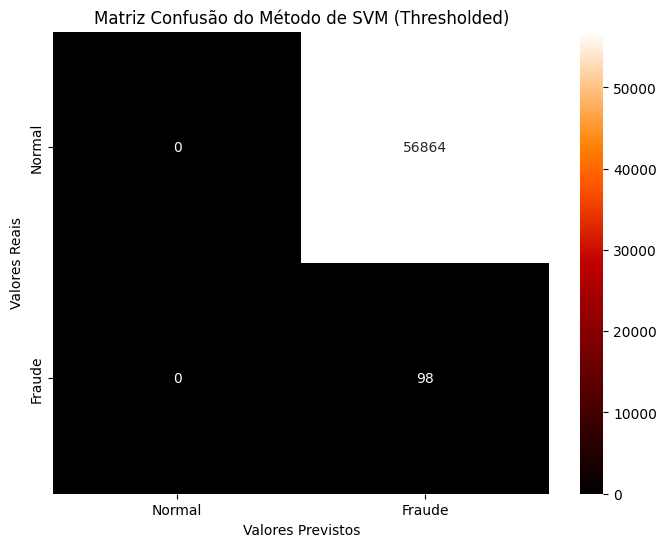

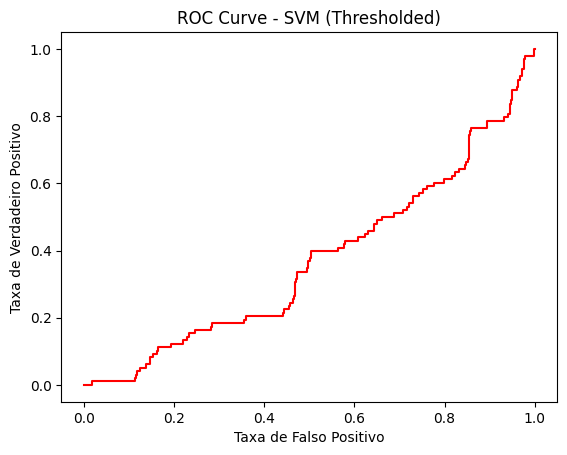

AUC - SVM:  0.3689346869867812



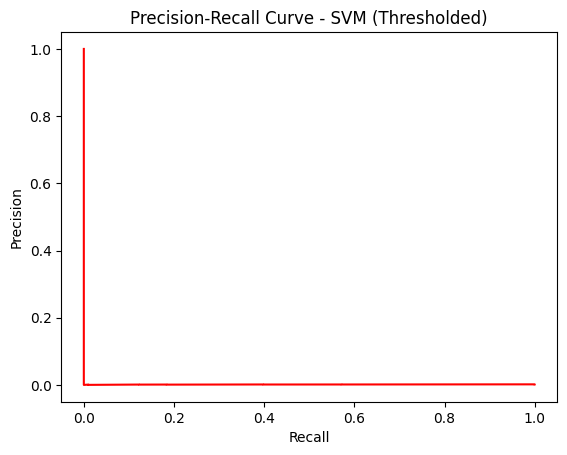

In [ ]:
# Get predicted probabilities for the positive class (fraud)
y_probs_SVM = SVM_model.predict_proba(X_test)[:, 1]

f1_scores_SVM = []
for threshold in thresholds:
    y_pred_threshold = (y_probs_SVM >= threshold).astype(int)
    f1_scores_SVM.append(f1_score(y_test, y_pred_threshold))

# Find the optimal threshold
optimal_threshold_SVM = thresholds[np.argmax(f1_scores_SVM)]
print(f"Optimal Threshold for SVM: {optimal_threshold_SVM:.4f}")

# Apply the optimal threshold to get predictions
y_pred_SVM_thresholded = (y_probs_SVM >= optimal_threshold_SVM).astype(int)

print("\nClassification Report (SVM with Optimal Threshold):")
print(classification_report(y_test, y_pred_SVM_thresholded))

# Matriz Confusão with Optimal Threshold
SVM_matriz_confusao_thresholded = confusion_matrix(y_test, y_pred_SVM_thresholded);

plt.figure(figsize=(8, 6))
sns.heatmap(SVM_matriz_confusao_thresholded, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de SVM (Thresholded)')
plt.show()

print()

# ROC Curve with Optimal Threshold
# The fpr_SVM and tpr_SVM are still based on the original full-feature SVM prediction.
# If SVM_model was indeed trained on reduced features, these plots might be inaccurate.
# For accuracy, it's best to re-generate these based on y_probs_SVM from X_test_reduced.
fpr_SVM_recalc, tpr_SVM_recalc, _ = roc_curve(y_test, y_probs_SVM)
plt.plot(fpr_SVM_recalc, tpr_SVM_recalc, color='red')
plt.title("ROC Curve - SVM (Thresholded)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC - SVM: ", roc_auc_score(y_test, y_probs_SVM))

print()
# Precision-Recall Curve with Optimal Threshold
# Similar to ROC, these plots should ideally be re-generated for accuracy.
precision_SVM_recalc, recall_SVM_recalc, _ = precision_recall_curve(y_test, y_probs_SVM)
plt.plot(recall_SVM_recalc, precision_SVM_recalc, color='red')
plt.title("Precision-Recall Curve - SVM (Thresholded)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## Regressão Logística (Features Reduzidas)

Vamos agora treinar e avaliar o modelo de Regressão Logística utilizando apenas o conjunto de features `V1-V28` e `Amount_scaled` (`X_reduced`).


Fitting Logistic Regression model (reduced features)...
Logistic Regression model (reduced features) fitted.

Classification Report (Regressão Logística - Features Reduzidas):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



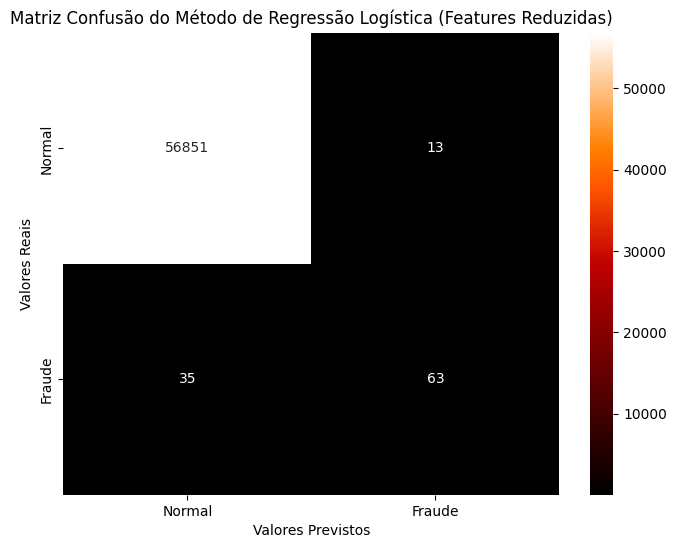

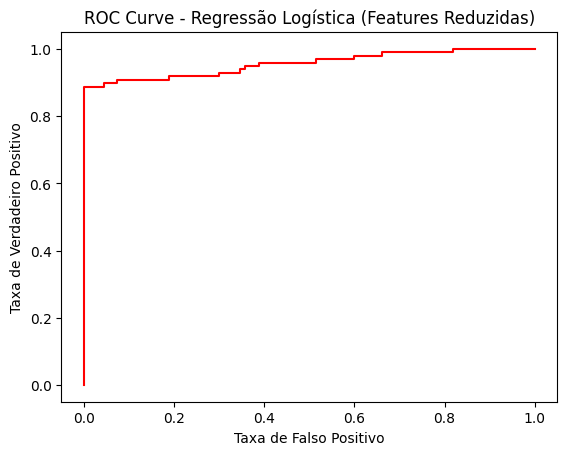

AUC (Regressão Logística - Features Reduzidas):  0.9559728259621236



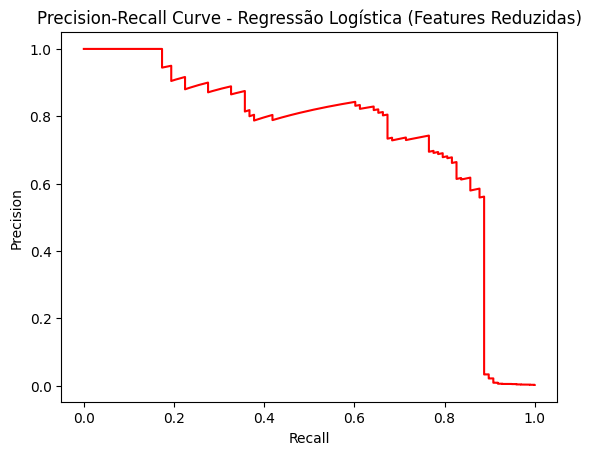

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

RL_model_reduced = LogisticRegression(max_iter=2000, random_state=42) # Aumentado max_iter para auxiliar na convergência

print("Fitting Logistic Regression model (reduced features)...")
RL_model_reduced.fit(X_train_reduced, y_train)
print("Logistic Regression model (reduced features) fitted.")

y_pred_RL_reduced = RL_model_reduced.predict(X_test_reduced)

print("\nClassification Report (Regressão Logística - Features Reduzidas):")
print(classification_report(y_test, y_pred_RL_reduced))

# Matriz Confusão
RL_matriz_confusao_reduced = confusion_matrix(y_test, y_pred_RL_reduced)

plt.figure(figsize=(8, 6))
sns.heatmap(RL_matriz_confusao_reduced, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de Regressão Logística (Features Reduzidas)')
plt.show()

print()

# Curva ROC
y_probs_RL_reduced = RL_model_reduced.predict_proba(X_test_reduced)[:,1]

fpr_RL_reduced, tpr_RL_reduced, _ = roc_curve(y_test, y_probs_RL_reduced)

plt.plot(fpr_RL_reduced, tpr_RL_reduced, color='red')
plt.title("ROC Curve - Regressão Logística (Features Reduzidas)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC (Regressão Logística - Features Reduzidas): ", roc_auc_score(y_test, y_probs_RL_reduced))

print()
# Curva Precision-Recall
precision_RL_reduced, recall_RL_reduced, _ = precision_recall_curve(y_test, y_probs_RL_reduced)

plt.plot(recall_RL_reduced, precision_RL_reduced, color='red')
plt.title("Precision-Recall Curve - Regressão Logística (Features Reduzidas)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Otimização de Limiar para Regressão Logística (Features Reduzidas)

Vamos encontrar o limiar ótimo para o modelo de Regressão Logística treinado com features reduzidas, maximizando o F1-score.

Optimal Threshold for Logistic Regression (Reduced Features): 0.1515

Classification Report (Regressão Logística - Features Reduzidas com Limiar Otimizado):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.77      0.75        98

    accuracy                           1.00     56962
   macro avg       0.87      0.88      0.88     56962
weighted avg       1.00      1.00      1.00     56962



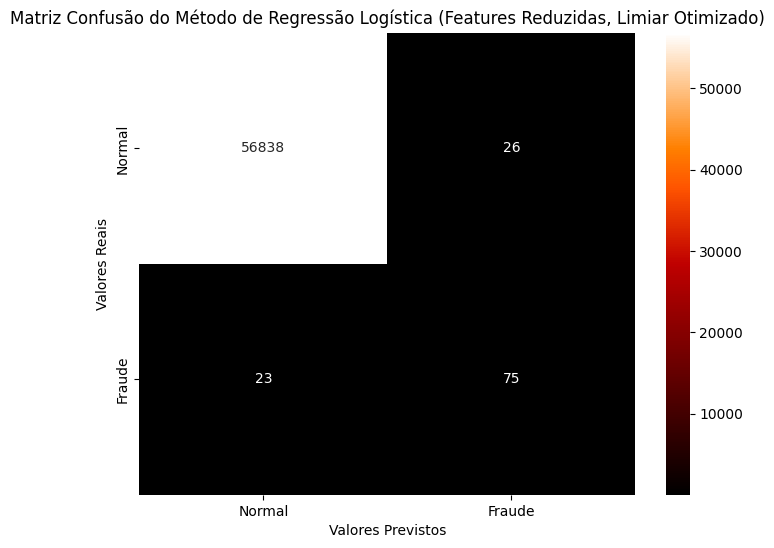

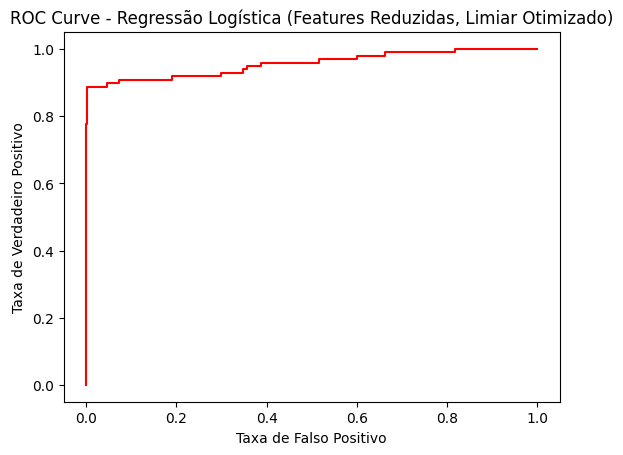

AUC (Regressão Logística - Features Reduzidas):  0.9559728259621236



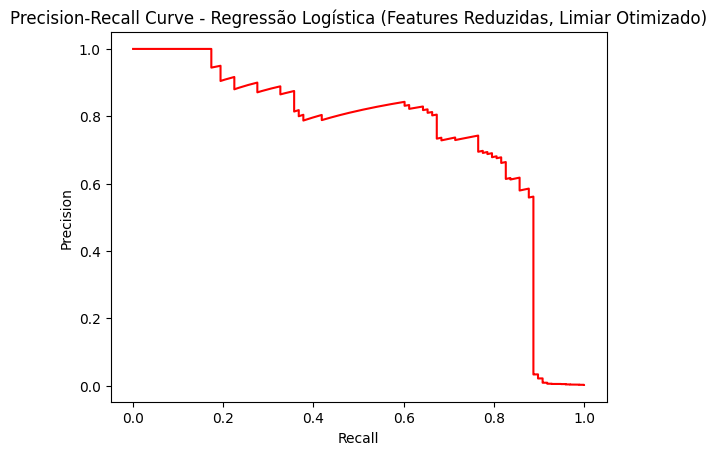

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Get predicted probabilities for the positive class (fraud)
y_probs_RL_reduced = RL_model_reduced.predict_proba(X_test_reduced)[:, 1]

# Define a range of thresholds to test
thresholds = np.linspace(0, 1, 100)

f1_scores_RL_reduced = []
for threshold in thresholds:
    y_pred_threshold_reduced = (y_probs_RL_reduced >= threshold).astype(int)
    f1_scores_RL_reduced.append(f1_score(y_test, y_pred_threshold_reduced))

# Find the optimal threshold
optimal_threshold_RL_reduced = thresholds[np.argmax(f1_scores_RL_reduced)]
print(f"Optimal Threshold for Logistic Regression (Reduced Features): {optimal_threshold_RL_reduced:.4f}")

# Apply the optimal threshold to get predictions
y_pred_RL_thresholded_reduced = (y_probs_RL_reduced >= optimal_threshold_RL_reduced).astype(int)

print("\nClassification Report (Regressão Logística - Features Reduzidas com Limiar Otimizado):")
print(classification_report(y_test, y_pred_RL_thresholded_reduced))

# Matriz Confusão with Optimal Threshold
RL_matriz_confusao_thresholded_reduced = confusion_matrix(y_test, y_pred_RL_thresholded_reduced)

plt.figure(figsize=(8, 6))
sns.heatmap(RL_matriz_confusao_thresholded_reduced, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de Regressão Logística (Features Reduzidas, Limiar Otimizado)')
plt.show()

print()

# ROC Curve with Optimal Threshold
plt.plot(fpr_RL_reduced, tpr_RL_reduced, color='red')
plt.title("ROC Curve - Regressão Logística (Features Reduzidas, Limiar Otimizado)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC (Regressão Logística - Features Reduzidas): ", roc_auc_score(y_test, y_probs_RL_reduced))

print()
# Precision-Recall Curve with Optimal Threshold
plt.plot(recall_RL_reduced, precision_RL_reduced, color='red')
plt.title("Precision-Recall Curve - Regressão Logística (Features Reduzidas, Limiar Otimizado)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## SVM (Features Reduzidas)

Agora, vamos treinar e avaliar o modelo SVM utilizando apenas o conjunto de features `V1-V28` e `Amount_scaled` (`X_reduced`). Espera-se que a convergência seja melhorada com features escaladas.

Fitting SVM model (reduced features, this may take a while)...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM model (reduced features) fitted.

Classification Report (SVM - Features Reduzidas):
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.00      0.07      0.00        98

    accuracy                           0.93     56962
   macro avg       0.50      0.50      0.48     56962
weighted avg       1.00      0.93      0.96     56962



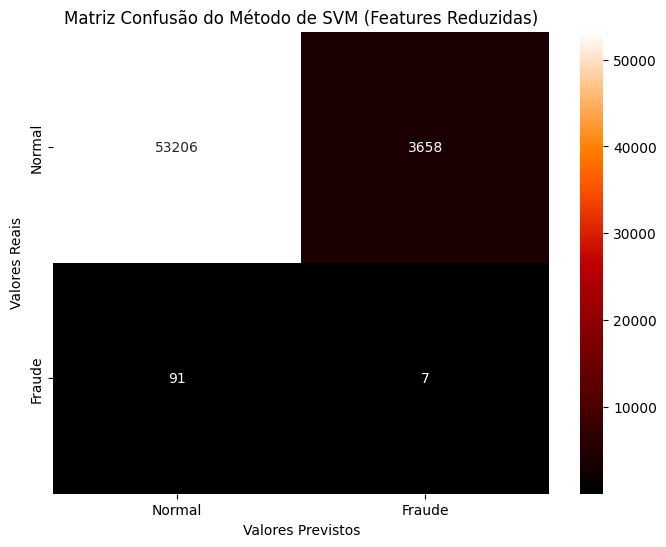

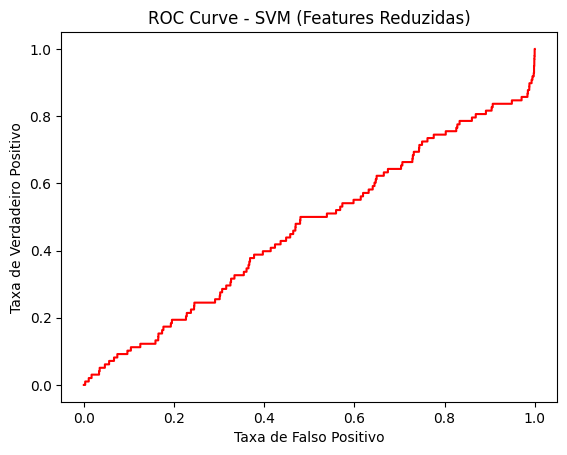

AUC (SVM - Features Reduzidas):  0.4664424893480183



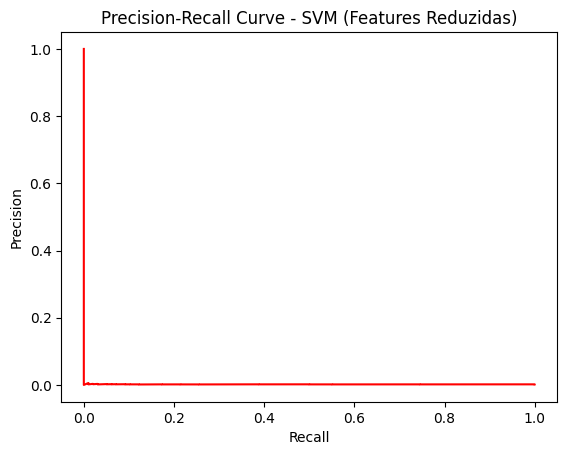

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Instantiate the SVM model
# Setting probability=True allows for predict_proba, which is needed for ROC and PR curves.
# class_weight='balanced' helps handle the imbalanced dataset.
# A linear kernel is often faster for large datasets, but radial basis function (rbf) is common too.
# max_iter is increased further to help with convergence on this dataset.
SVM_model_reduced = SVC(kernel='linear', C=1, class_weight='balanced', random_state=42, probability=True, max_iter=10000) # Increased max_iter for reduced features

print("Fitting SVM model (reduced features, this may take a while)...")
SVM_model_reduced.fit(X_train_reduced, y_train)
print("SVM model (reduced features) fitted.")

y_pred_SVM_reduced = SVM_model_reduced.predict(X_test_reduced)

print("\nClassification Report (SVM - Features Reduzidas):")
print(classification_report(y_test, y_pred_SVM_reduced))

# Matriz Confusão
SVM_matriz_confusao_reduced = confusion_matrix(y_test, y_pred_SVM_reduced);

plt.figure(figsize=(8, 6))
sns.heatmap(SVM_matriz_confusao_reduced, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de SVM (Features Reduzidas)')
plt.show()

print()

# Curva ROC
y_probs_SVM_reduced = SVM_model_reduced.predict_proba(X_test_reduced)[:,1]

fpr_SVM_reduced, tpr_SVM_reduced, _ = roc_curve(y_test, y_probs_SVM_reduced)

plt.plot(fpr_SVM_reduced, tpr_SVM_reduced, color='red')
plt.title("ROC Curve - SVM (Features Reduzidas)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC (SVM - Features Reduzidas): ", roc_auc_score(y_test, y_probs_SVM_reduced))

print()
# Curva Precision-Recall
precision_SVM_reduced, recall_SVM_reduced, _ = precision_recall_curve(y_test, y_probs_SVM_reduced)

plt.plot(recall_SVM_reduced, precision_SVM_reduced, color='red')
plt.title("Precision-Recall Curve - SVM (Features Reduzidas)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### Otimização de Limiar para SVM (Features Reduzidas)

Por fim, vamos otimizar o limiar para o modelo SVM treinado com features reduzidas.

Optimal Threshold for SVM (Reduced Features): 0.0000

Classification Report (SVM - Features Reduzidas com Limiar Otimizado):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     56864
           1       0.00      1.00      0.00        98

    accuracy                           0.00     56962
   macro avg       0.00      0.50      0.00     56962
weighted avg       0.00      0.00      0.00     56962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


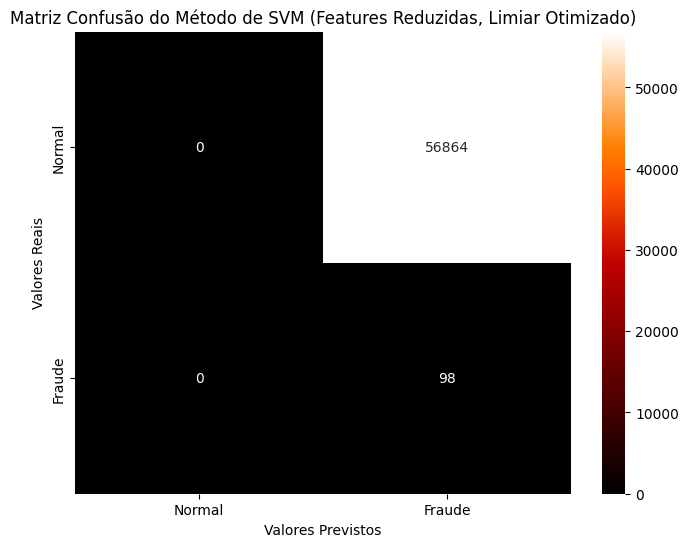

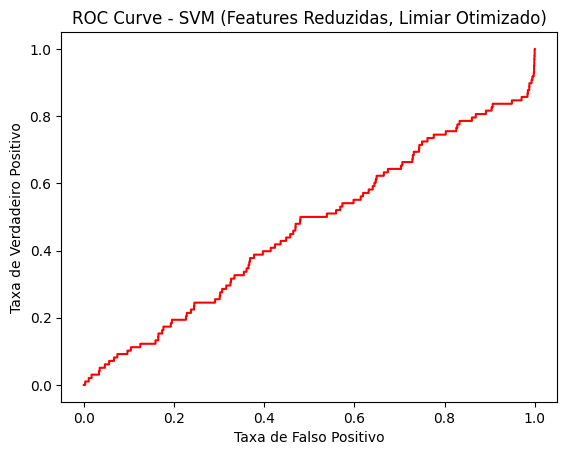

AUC (SVM - Features Reduzidas):  0.4664424893480183



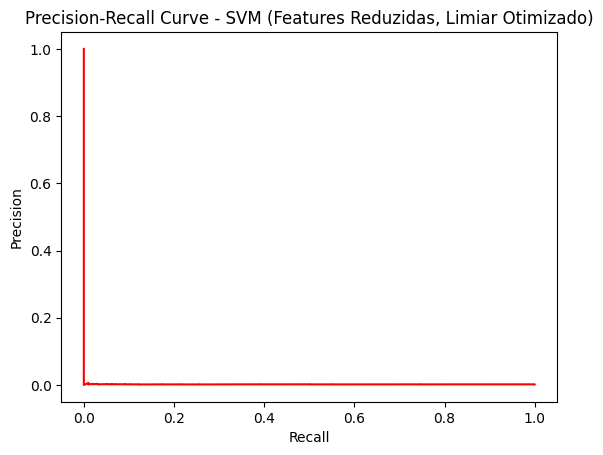

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Get predicted probabilities for the positive class (fraud)
y_probs_SVM_reduced = SVM_model_reduced.predict_proba(X_test_reduced)[:, 1]

# Define a range of thresholds to test
thresholds = np.linspace(0, 1, 100)

f1_scores_SVM_reduced = []
for threshold in thresholds:
    y_pred_threshold_reduced = (y_probs_SVM_reduced >= threshold).astype(int)
    f1_scores_SVM_reduced.append(f1_score(y_test, y_pred_threshold_reduced))

# Find the optimal threshold
optimal_threshold_SVM_reduced = thresholds[np.argmax(f1_scores_SVM_reduced)]
print(f"Optimal Threshold for SVM (Reduced Features): {optimal_threshold_SVM_reduced:.4f}")

# Apply the optimal threshold to get predictions
y_pred_SVM_thresholded_reduced = (y_probs_SVM_reduced >= optimal_threshold_SVM_reduced).astype(int)

print("\nClassification Report (SVM - Features Reduzidas com Limiar Otimizado):")
print(classification_report(y_test, y_pred_SVM_thresholded_reduced))

# Matriz Confusão with Optimal Threshold
SVM_matriz_confusao_thresholded_reduced = confusion_matrix(y_test, y_pred_SVM_thresholded_reduced);

plt.figure(figsize=(8, 6))
sns.heatmap(SVM_matriz_confusao_thresholded_reduced, annot=True, fmt='d', cmap='gist_heat',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.xlabel('Valores Previstos')
plt.ylabel('Valores Reais')
plt.title('Matriz Confusão do Método de SVM (Features Reduzidas, Limiar Otimizado)')
plt.show()

print()

# ROC Curve with Optimal Threshold
plt.plot(fpr_SVM_reduced, tpr_SVM_reduced, color='red')
plt.title("ROC Curve - SVM (Features Reduzidas, Limiar Otimizado)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.show()

print("AUC (SVM - Features Reduzidas): ", roc_auc_score(y_test, y_probs_SVM_reduced))

print()
# Precision-Recall Curve with Optimal Threshold
plt.plot(recall_SVM_reduced, precision_SVM_reduced, color='red')
plt.title("Precision-Recall Curve - SVM (Features Reduzidas, Limiar Otimizado)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()